PROJETO FINAL - ANALISE DE MANUTENÇÃO DE MAQUINAS PARA FABRICAS

Fase 1 — Análise Exploratória (EDA)

1.1 - Importar Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#preconfiguração de visualização
pd.set_option('display.float_format', '{:.3f}'.format)

1.2 - Leitura e Backup da Base de dados

In [3]:
df_original = pd.read_csv('data/manutencao_preditiva.csv')   # base original intocável
df_ler = df_original.copy()                                  # cópia de trabalho
df_ler.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.100,308.600,1551.000,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408.000,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498.000,49.400,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408.000,40.000,9,0,0,0,0,0,0


In [4]:
df_ler.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

In [5]:
df_ler.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.000,9500.000,9500.000,9500.000,9500.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.002,310.001,1539.245,39.974,107.951,0.034,0.005,0.011,0.009,0.010,0.002
std,2886.896,2.002,1.486,180.274,9.995,63.654,0.181,0.068,0.107,0.097,0.099,0.044
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.100,53.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5000.500,300.100,310.100,1504.000,40.100,108.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,7500.250,301.500,311.100,1613.000,46.700,162.000,0.000,0.000,0.000,0.000,0.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000,1.000,1.000,1.000,1.000,1.000


1.3 - Analise inicial

Como podemos ver acima o dataset possui 10000 linhas e 14 colunas composta por identificadores, atributos de sensores e a variável alvo (falha__maquina). 
nas colunas (temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm e torque_nm) temos valores ausentes que precisam ser tratados na limpeza.

a variável alvo (falha__maquina) só tem ~3% dos registros que representam falha classe1 os outros ~97% de registros representam operação normal classe0

as variaveis (temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm e torque_nm) tem valores em escalas muito distintas isso precisa ser tratado para o uso do KNN

Quanto à distribuição, as temperaturas apresentam média e mediana praticamente iguais, enquanto velocidade_rotacao_rpm tem média maior que a mediana e valores máximos muito acima do 3º quartil.



1.4 — Gráficos

 1.4.1 — Grafico 1 — Desbalanceamento da variável alvo (gráfico de barras).

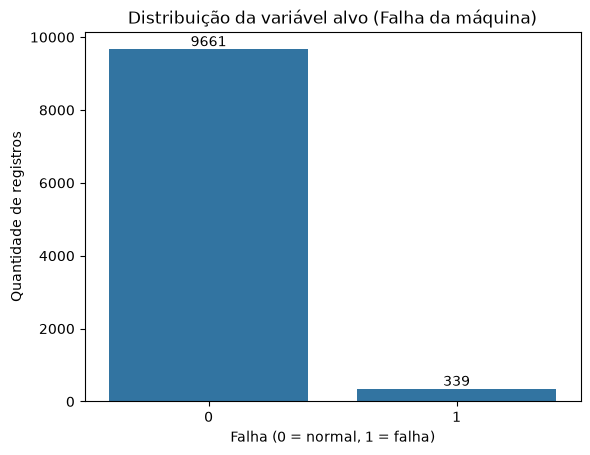

In [6]:
ax = sns.countplot(data=df_ler, x='falha_maquina') 
for container in ax.containers:      
    ax.bar_label(container)
plt.title('Distribuição da variável alvo (Falha da máquina)')
plt.xlabel('Falha (0 = normal, 1 = falha)')
plt.ylabel('Quantidade de registros')
plt.show()   


1.4.2 — Gráfico 2 — Histograma de distribuição das variáveis preditoras.

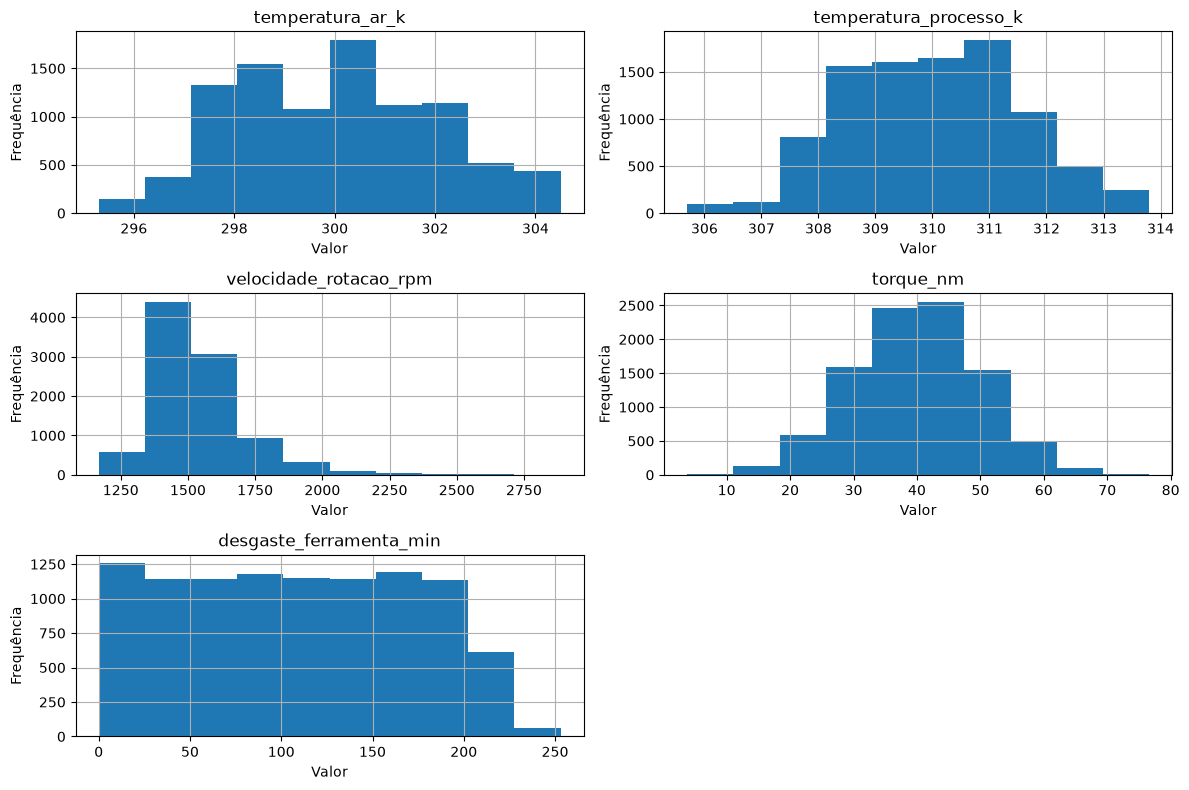

In [7]:
colunas_sensores = ['temperatura_ar_k','temperatura_processo_k','velocidade_rotacao_rpm','torque_nm','desgaste_ferramenta_min']

eixos = df_ler[colunas_sensores].hist(figsize=(12,8))

for linha in eixos:
    for ax in linha:
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

1.4.3 — Gráfico 3 — Heatmap de correlação de Pearson.

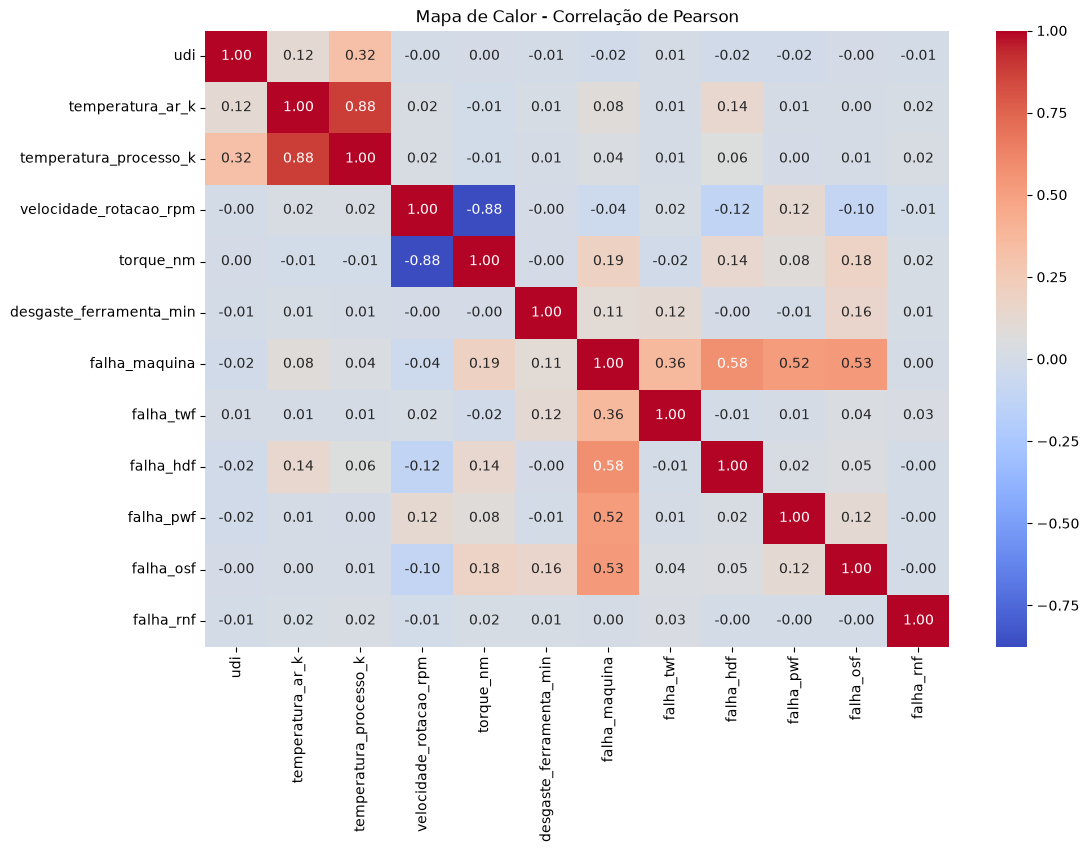

In [8]:
plt.figure(figsize=(12,8))
matriz_corr = df_ler.corr(numeric_only=True)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor - Correlação de Pearson')
plt.show()

1.5 - Analise dos Graficos

Ponto 1 as falha_hdf, falha_osf, falha_pwf e falha_twf têm correlação relevante com falha_maquina porque são a causa da falha. Por isso serão removidas do X para evitar que o modelo acerte tudo afinal esses são os motivos reais das falhas.

Ponto 2 existe uma relação forte entre as temperaturas do ar e do processo indicado pelo 0.88 e tambem entre rotação e torque indicado pelo -0.88 no grafico do heatmap

Ponto 3 uma correlação fraca entre as variaveis que podem gerar uma predição os numeros variam de 0.04 a no maximo 0.19

Ponto 4 No hhistograma temos que: 
1 - temperatura_ar_k é razoavelmente simétrico com valores proximos a 300k
2 - temperatura_processo_k também em sino simétrico com valor proximo a 310k
3 - a velocidade_rotacao_rpm fortemente assimétrica a maioria dos valores se 
concentra em ~1.400–1.500. mas há uma cauda longa puxando até ~2.800 
4 - torque_nm é simétrico, centrado em ~40 Nm.
5 - desgaste_ferramenta_min a distribuição é quase uniforme proximo a ~200 e só depois de 200 ela cai.

Ponto 5 - o Grafico 1 de barras evidencia o um numero muito baixo de falhas, por isso sera necessario usar uma tecnica de balancemaento para que os dados coletados possam ser usados para treinar o modelo.

Fase 2 — Limpeza e Tratamento de Dados (Data Prep)

2.1 - Verficação de Duplicados

In [9]:
print('Duplicados (Todas colunas menos udi) =', df_ler.duplicated(subset=df_ler.columns.drop('udi')).sum())

Duplicados (Todas colunas menos udi) = 0


não hà registros duplicados, para analise foi ignorada a coluna udi que é só um indice

2.2 - Verificação de dados nulos

In [10]:
print('\nValores ausentes por coluna:')
print(df_ler.isnull().sum())


Valores ausentes por coluna:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64


In [11]:
df_ler[df_ler.isnull().any(axis=1)].head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
14,15,L47194,L,NaN,NaN,NaN,NaN,40,0,0,0,0,0,0
29,30,L47209,L,NaN,NaN,NaN,NaN,84,0,0,0,0,0,0
31,32,L47211,L,NaN,NaN,NaN,NaN,89,0,0,0,0,0,0
33,34,L47213,L,NaN,NaN,NaN,NaN,93,0,0,0,0,0,0


- Como podemos ver existem quatro colunas com 500 registro ausentes cada

- Vamos manter todas as linhas com valores nulos e substituir os valores nulos pela media ou mediana

- Para decidir sobre media e mediana vamos analisar o boxplot abaixo.

2.3 - Boxplots para identificar outliers nas variáveis explicativas

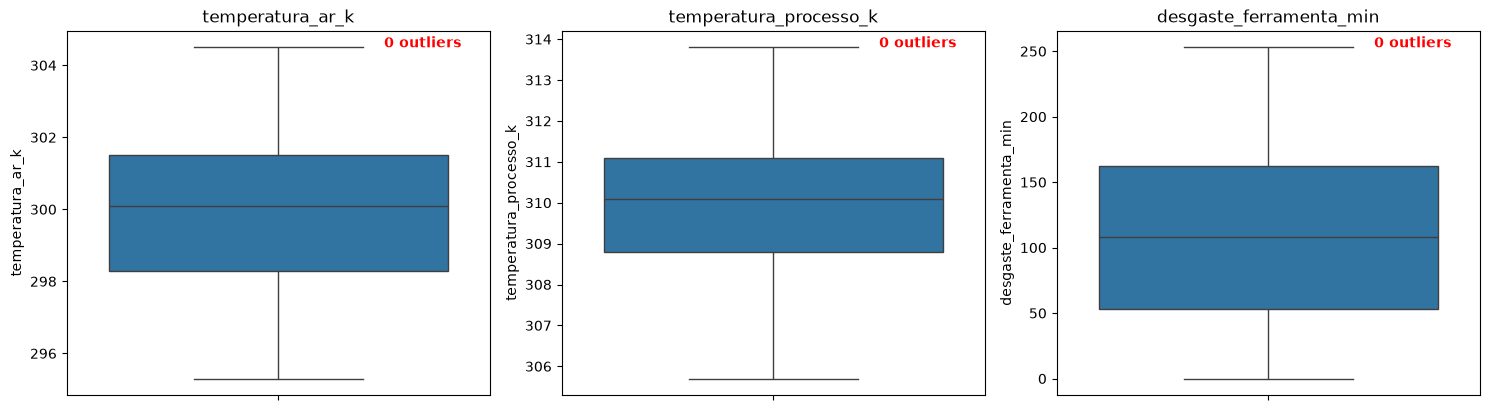

In [12]:
colunas_sensores = ['temperatura_ar_k', 'temperatura_processo_k', 'desgaste_ferramenta_min']

plt.figure(figsize=(15, 8))
for i, coluna in enumerate(colunas_sensores):
    Q1 = df_ler[coluna].quantile(0.25)
    Q3 = df_ler[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    qtd_outliers = df_ler[(df_ler[coluna] < limite_inferior) | (df_ler[coluna] > limite_superior)][coluna].count()

    ax = plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_ler[coluna])
    plt.title(coluna)

    # escreve a contagem dentro do gráfico, ao lado dos outliers de cima
    ax.text(0.25, df_ler[coluna].max(), f'{qtd_outliers} outliers', color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

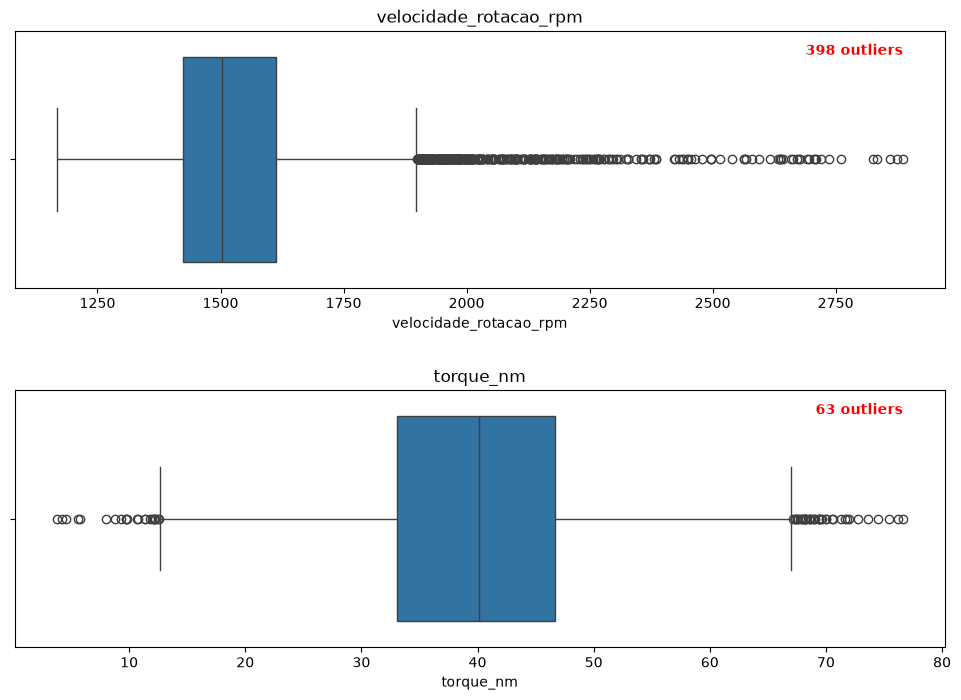

In [13]:
colunas_sensores = ['velocidade_rotacao_rpm', 'torque_nm']

plt.figure(figsize=(12, 8))
for i, coluna in enumerate(colunas_sensores):
    Q1 = df_ler[coluna].quantile(0.25)
    Q3 = df_ler[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    qtd_outliers = df_ler[(df_ler[coluna] < limite_inferior) | (df_ler[coluna] > limite_superior)][coluna].count()

    ax = plt.subplot(2, 1, i + 1)        
    sns.boxplot(x=df_ler[coluna])
    plt.title(coluna)

    # contagem no canto superior direito, dentro do gráfico
    ax.text(df_ler[coluna].max(), -0.45, f'{qtd_outliers} outliers', color='red', fontsize=10, fontweight='bold', ha='right', va='top')

plt.subplots_adjust(hspace=0.4)
plt.show()

2.4 - Analise e Conclusão

 - Como podemos ver no Boxplot as variaveis (temperatura_ar_k, temperatura_processo_k e desgaste_ferramenta_min) não tem
outliers, existe uma boa simetria nos numeros, logo a média representa bem este conjunto de dados.

 - A velocidade_rotacao_rpm tem 398 outliers concentrados a direita o que significa que tem muitas maquinas trabalhando com rotação do motor
acima do padrão chegando até o limite de ~2886 rpm, ja aqui devemos usar a mediana para representar um melhor equilibrio dos numeros.

 - Ja a variavel torque_nm tem 63 outliers distribuidos nas duas extremidades, aqui temos maquinas trabalhando bem abaixo e bem acima do padrão, mas neste caso a mediana traz um melhor equilibrio para os numeros.

Conclusão: devemos manter todas as linhas com outliers, pois eles mesmo extremos são indicios fortissimo de possiveis motivos de falhas e como as falhas são raras nos registros, removelos apagaria informação uteis e valiosas.

Sobre as linhas com informações nulas: 
 - Para as colunas (temperatura_ar_k, temperatura_processo_k) vamos substituir os nulos pela media, pois como vemos no boxplot ela representa bem este conjunto de dados. 
 - Para as colunas (velocidade_rotacao_rpm, torque_nm) vamos substituir os nulos pela mediana, pois como vemos no boxplot ela representa bem este conjunto de dados.

2.4 - Imputação de dados (substituição de dados nulos pela media e mediana)

In [14]:
# Média nas colunas simétricas (sem outliers)
df_ler['temperatura_ar_k'] = df_ler['temperatura_ar_k'].fillna(df_ler['temperatura_ar_k'].mean())
df_ler['temperatura_processo_k'] = df_ler['temperatura_processo_k'].fillna(df_ler['temperatura_processo_k'].mean())

# Mediana nas colunas com outliers
df_ler['velocidade_rotacao_rpm'] = df_ler['velocidade_rotacao_rpm'].fillna(df_ler['velocidade_rotacao_rpm'].median())
df_ler['torque_nm'] = df_ler['torque_nm'].fillna(df_ler['torque_nm'].median())

# Verificação: conferir que não sobrou nenhum nulo
print('\nValores ausentes por coluna após tratamento:')
print(df_ler.isnull().sum())

# --- EXEMPLO: linhas que antes tinham NaN, agora preenchidas ---
print('\nExemplo de linhas que antes tinham NaN, agora preenchidas:')
df_ler.loc[[3,14,29,31,33]]



Valores ausentes por coluna após tratamento:
udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

Exemplo de linhas que antes tinham NaN, agora preenchidas:


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,300.002,310.001,1504.000,40.100,7,0,0,0,0,0,0
14,15,L47194,L,300.002,310.001,1504.000,40.100,40,0,0,0,0,0,0
29,30,L47209,L,300.002,310.001,1504.000,40.100,84,0,0,0,0,0,0
31,32,L47211,L,300.002,310.001,1504.000,40.100,89,0,0,0,0,0,0
33,34,L47213,L,300.002,310.001,1504.000,40.100,93,0,0,0,0,0,0


Fase 3 — Feature Engineering

3.1 - Criação de novas colunas (Potência mecânica, Diferença de temperatura, Esforço mecânico acumulado)

In [15]:
# Potência mecânica (rotação x torque)
df_ler['potencia'] = (df_ler['velocidade_rotacao_rpm'] * df_ler['torque_nm'])

# Diferença de temperatura (dissipação de calor: processo acima do ambiente)
df_ler['diferenca_temperatura'] = df_ler['temperatura_processo_k'] - df_ler['temperatura_ar_k']

# Esforço mecânico acumulado (desgaste x torque)
df_ler['esforco_mecanico'] = df_ler['desgaste_ferramenta_min'] * df_ler['torque_nm']

# Conferência das novas colunas
df_ler[['velocidade_rotacao_rpm', 'torque_nm', 'potencia','temperatura_processo_k', 
        'temperatura_ar_k', 'diferenca_temperatura','desgaste_ferramenta_min', 'esforco_mecanico']].head()

,velocidade_rotacao_rpm,torque_nm,potencia,temperatura_processo_k,temperatura_ar_k,diferenca_temperatura,desgaste_ferramenta_min,esforco_mecanico
0,1551.000,42.800,66382.800,308.600,298.100,10.500,0,0.000
1,1408.000,46.300,65190.400,308.700,298.200,10.500,3,138.900
2,1498.000,49.400,74001.200,308.500,298.100,10.400,5,247.000
3,1504.000,40.100,60310.400,310.001,300.002,9.999,7,280.700
4,1408.000,40.000,56320.000,308.700,298.200,10.500,9,360.000


3.2 - Transformação da coluna tipo em numero ordinal

In [16]:
# Encoding ordinal da coluna 'tipo': L=0, M=1, H=2
mapa_tipo = {'L': 0, 'M': 1, 'H': 2}
df_ler['tipo'] = df_ler['tipo'].map(mapa_tipo)

# Conferência
df_ler[['tipo']].head()

,tipo
0,1
1,0
2,0
3,0
4,0


3.4 - Conclusão da Fase 3

 - Nesta fase foram criadas novas variaveis e a variavel 'tipo' foi convertida
 - Criada variavel 'potencia' pela fornmula, potencia = velocidade_rotacao_rpm × torque_nm, esta potencia é proporcional a potencia real do motor e esta variavel resume o esforço do equipamento.
 - Criada variavel 'diferença de temperatura' pela fórmula diferenca_temperatura = temperatura_processo_k − temperatura_ar_k, esta variavel mede o gradiente de temperatura, o quanto o processo aquece acima do ambiente, quanto menor esse gradiente, pior a dissipação de calor, logo temos indicio de superaquecimento.
 - Criada a variavel 'esforço mecanico' pela fórmula, esforco_mecanico = desgaste_ferramenta_min × torque_nm, esta variavel representa a tensão mecânica acumulada: uma ferramenta muito desgastada operando sob torque elevado sofre maior estresse.
 - a variavel tipo sera mantida e para isso precisou ser convertida em numero, preservando a hierarquia com encoding ordinal onde (L=0, M=1, H=2) uma vez que os modelos só trabalham com numeros.

Importante: essas novas features reconstroem a lógica física dos motivos de falha (falha_hdf = calor, falha_osf = sobrecarga, falha_pwf = potência) usando apenas dados gerados pelos sensores. assim, o modelo ganha poder preditivo sem utilizar as colunas de motivo, que causariam vazamento de dados (data leakage).

Fase 4 — Divisão e Balanceamento

4.1 - Separar X (preditoras) e y (alvo).

In [17]:
# Colunas que NÃO entram no X
colunas_remover = ['udi', 'id_produto', 'falha_maquina',
'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']

X = df_ler.drop(columns=colunas_remover) # preditoras
Y = df_ler['falha_maquina']              # alvo

# Conferência do que sobrou no X
print('Colunas do X:', list(X.columns))
print('Formato do X:', X.shape)
print('Formato do Y:', Y.shape)

Colunas do X: ['tipo', 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia', 'diferenca_temperatura', 'esforco_mecanico']
Formato do X: (10000, 9)
Formato do Y: (10000,)


4.2 - Dividir em treino (80%) e teste (20%) com stratify=y

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.2,                       # reserva 20% dos dados para teste, 80% para treino.
    stratify=Y,                          # mantem a proporção de falhas em treino e teste
    random_state=42,                     # garante reprodutibilidade do resultado (mesma divisão sempre)
    )

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('\nProporção de falhas no treino:')
print(Y_train.value_counts(normalize=True).round(3))   
print('\nProporção de falhas no teste:')
print(Y_test.value_counts(normalize=True).round(3))

Treino: (8000, 9) | Teste: (2000, 9)

Proporção de falhas no treino:
falha_maquina
0   0.966
1   0.034
Name: proportion, dtype: float64

Proporção de falhas no teste:
falha_maquina
0   0.966
1   0.034
Name: proportion, dtype: float64


4.3 - Balanceamento (só no treino).

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)

print('Antes do SMOTE:', Y_train.value_counts().to_dict())
print('Depois do SMOTE:', Y_train_bal.value_counts().to_dict())

Antes do SMOTE: {0: 7729, 1: 271}
Depois do SMOTE: {0: 7729, 1: 7729}


4.4 - Conclusão da fase 4:
 - Primeiro em 4.1, foi feita a separação das colunas para que ficassem fora do X, as colunas udi', 'id_produto', são identificadores e não tem valor para o aprendizado, a coluna 'falha_maquina' é o nosso alvo logo nosso Y, e as colunas
'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf' são os motivos reais das falhas, elas devem sair para garantir que não tenha data leakage

- Depois em 4.2, fizemos a divisão dos dados para treino e teste onde foram separados 80% dos dados para treino e 20% para teste e usamos 
o stratify em Y mantem a proporção de falhas em treino e teste.

- Logo em seguida em 4.3, fizemos o balanceamento dos dados de treino, usando a tecnica do SMOTE, optei por ela porque ela cria exemplos sintéticos novos da classe minoritária (falhas), até equilibrar. Mantém todos os dados da classe majoritária. não usei a Random Under Sampling pois ela remove exemplos da classe majoritária até equilibrar, isso faria perder dados e uma vez que o numero de falhas é muito pequeno ficariamos com poucos dados.


Fase 5 — Escalonamento (StandardScaler)

5.1 - Definindo o fit_transform e transform

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal) #aprende no treino balanceado e aplica a transformação
X_test_scaled = scaler.transform(X_test)           # aplica a mesma transformação no teste (sem aprender nada)

print('Treino escalonado:', X_train_scaled.shape)
print('Teste escalonado:', X_test_scaled.shape)

Treino escalonado: (15458, 9)
Teste escalonado: (2000, 9)


5.2 - Conclusão da fase 5:
 - Usei o fit_transform (aprende as estatisticas) para escalonar o treino e o transform (só aplica) para no teste  no KNN, uma vez que este modelo classifica por distancia, variaveis com escalas diferentes (potencia em milhares e torque em dezenas), distorceriam o cálculo. o standarscaler transforma os dados para terem média 0 e desvio-padrão 1, deixando todas as variáveis na mesma escala.
 - o escalonamento foi usado em todos as 9 colunas de variaveis. embora a variavel 'tipo' tenha escala unitaria (0,1,2), esta transformação não prejudica o resultado.
 - A Arvore de Decisões ira usar os dados Crus  (X_train_bal, X_test) uma vez que este modelo usa perguntas para fazer a triagem em cada variavel, exemplo. torque >30 sim? ou não? e assim vai reagrupando os dados de 2 em 2 até chegar na resposta. então o escalonamento aqui seria irrelevante para o resultado.

Fase 6 — Ajuste de Parâmetros e Combate ao Overfitting

6.1 - Etapa 1 — Testar o KNN variando K (3, 5, 7)

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in  [3, 5 , 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train_bal)        # treina com o treino escalonado e balanceado
    
    acc_treino = accuracy_score(Y_train_bal, knn.predict(X_train_scaled))
    acc_teste = accuracy_score(Y_test, knn.predict(X_test_scaled))

    print(f'k={k}: Acurácia Treino = {acc_treino:.3f} | Acurácia Teste = {acc_teste:.3f}')

k=3: Acurácia Treino = 0.979 | Acurácia Teste = 0.921
k=5: Acurácia Treino = 0.969 | Acurácia Teste = 0.912
k=7: Acurácia Treino = 0.963 | Acurácia Teste = 0.907


6.2 - Etapa 2 — Testar a Árvore de Decisão variando max_depth (3, 5, None).

In [22]:
from sklearn.tree import DecisionTreeClassifier

for profundidade in [3, 5, None]:
   arvore = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
   arvore.fit(X_train_bal, Y_train_bal)        # dados CRUS (sem escalonar)
   
   acctree_treino = accuracy_score(Y_train_bal, arvore.predict(X_train_bal))
   acctree_teste = accuracy_score(Y_test, arvore.predict(X_test))
   
   print(f'Profundidade={profundidade}: Acurácia Treino = {acctree_treino:.3f} | Acurácia Teste = {acctree_teste:.3f}')

Profundidade=3: Acurácia Treino = 0.869 | Acurácia Teste = 0.855
Profundidade=5: Acurácia Treino = 0.930 | Acurácia Teste = 0.948
Profundidade=None: Acurácia Treino = 0.999 | Acurácia Teste = 0.955


6.3 - Conclusão da Fase 6:

 - No modelo KNN, testamos as variações K = 3, 5, 7, observamos que quanto maior o valor de k (k=3 = 0.979,  → k=7 = 0.963) menor é a acurácia, pois quando aumentamos a quantidade de vizinhos o modelo decora menos, nas 3 configurações testadas temos o k=3 com a melhor performace de acurácia entre treino e teste, com baixo overfitting.

 - Na Arvore de decisão, variando max_depth = 3, 5, None. Temos: max_depth = 3, com underfitting (subajuste) pois o treino e teste ficaram com acurácia baixa (0.869 e 0.855) isso foi simples demais. max_depth = 5, com um equilibrio ideal entre treino e teste com uma boa acurácia de (0.930 e 0.948) sem overfitting. max_depth = None, overfitting claro, com as respectivas acurácias de treino e teste de (0.999 e 0.955) arvore decorou os treinos. 

 - Logo o overfitting apareceu claramente na Árvore com max_depth=None (treino ~100%), e a estabilidade veio com max_depth=5. e as melhores configurações, ficaram: KNN com K=3 e Árvore com max_depth=5, que serão comparados no veredito final.

Fase 7 — Avaliação e Veredito Final

In [23]:
# --- Melhor KNN (K=3) — usa dados ESCALONADOS ---

melhor_knn = KNeighborsClassifier(n_neighbors=3)
melhor_knn.fit(X_train_scaled, Y_train_bal)      
acc_knn= accuracy_score(Y_test, melhor_knn.predict(X_test_scaled))

# --- Melhor Árvore (max_depth=5) — usa dados CRUS ---

melhor_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
melhor_arvore.fit(X_train_bal, Y_train_bal)
acc_arvore = accuracy_score(Y_test, melhor_arvore.predict(X_test))


# --- Comparação ---
print(f'Acurácia Final KNN (k=3): {acc_knn:.3f}')
print(f'Acurácia Final Árvore (depth=5): {acc_arvore:.3f}')

if acc_arvore > acc_knn:
    print("\nVeredito Final: a Árvore de Decisão teve o melhor desempenho no teste.")
else:
    print("\nVeredito Final: o KNN teve o melhor desempenho no teste.")

Acurácia Final KNN (k=3): 0.921
Acurácia Final Árvore (depth=5): 0.948

Veredito Final: a Árvore de Decisão teve o melhor desempenho no teste.


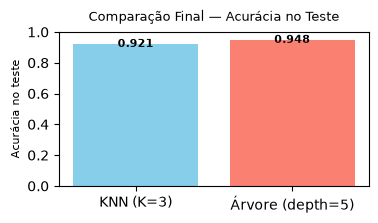

In [24]:
#Grafico de barras comparando os dois modelos

modelos = ['KNN (K=3)', 'Árvore (depth=5)']
acuracias = [acc_knn, acc_arvore]

plt.figure(figsize=(4, 2))
barras = plt.bar(modelos, acuracias, color=['skyblue', 'salmon'])

plt.ylim(0, 1)                          # eixo de 0 a 1 (acurácia)
plt.ylabel('Acurácia no teste', fontsize=8)
plt.title('Comparação Final — Acurácia no Teste', fontsize=9, pad=8)

# escreve o valor em cima de cada barra
for barra in barras:
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
             f'{barra.get_height():.3f}', ha='center', va='center', fontweight='bold', fontsize=8)

plt.show()

7.1 - Importância de cada variável da Arvore de decisão

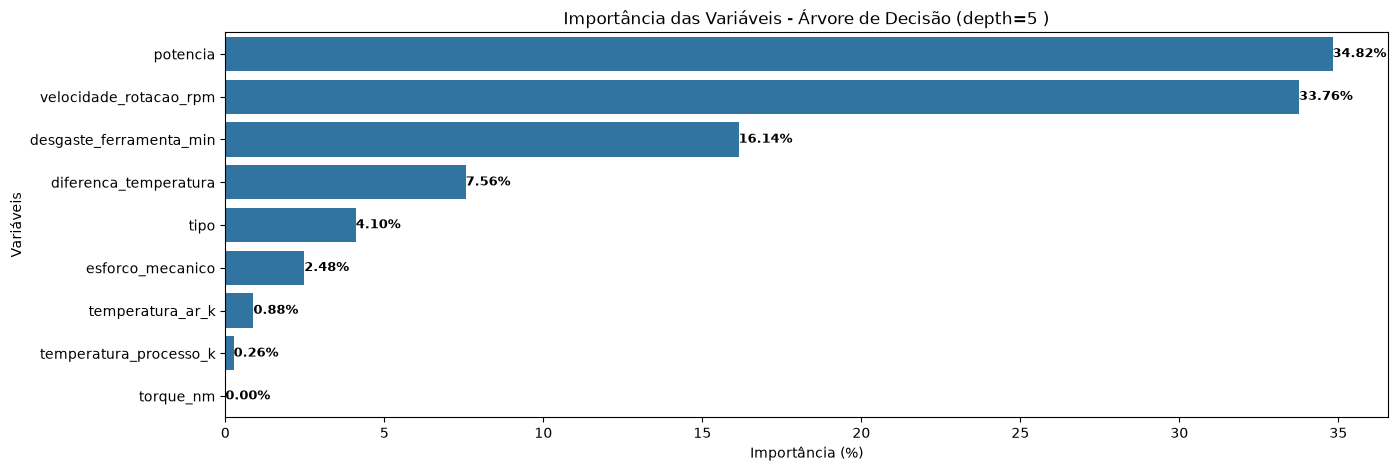

In [25]:
# Importância de cada variável (ordenada da maior para a menor)

importancia = (pd.Series(melhor_arvore.feature_importances_, index=X.columns) * 100) .sort_values(ascending=False)

plt.figure(figsize=(15,5))
ax = sns.barplot(x=importancia.values, y=importancia.index) 
plt.title('Importância das Variáveis - Árvore de Decisão (depth=5 )')
plt.xlabel('Importância (%)')
plt.ylabel('Variáveis')

# escreve o % dentro de cada barra

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=9, color='black', fontweight='bold')
    
plt.show()

Conclusão da Fase 7 — Veredito Final:

A acurácia de teste reflete como o modelo se comporta com dados novos, por isso ela é mais importante para o veredito final. E, como podemos ver, o modelo de Árvore de Decisão com a configuração (depth=5) obteve uma acurácia no teste de 0.948, contra 0.921 do modelo KNN na configuração (k=3). Portanto, ela apresentou o melhor desempenho na generalização da previsão de falhas futuras em máquinas.

Além da melhor acurácia, ela também teve a melhor estabilidade entre treino e teste (0.930 e 0.948), sem overfitting, e isso indica um modelo confiável.  Sua adoção também é favorecida pela simplicidade operacional, não exigindo escalonamento dos dados, o que facilita colocá-la em produção.

Outro diferencial da Árvore é que ela permite saber quais variáveis influenciaram mais no resultado, isso é importante para a equipe de manutenção entender os motivos e riscos de falhas. A análise de importância das variáveis mostrada no gráfico acima confirmou que a feature criada potencia foi a mais relevante (34,82%), seguida da velocidade_rotacao_rpm (33,76%) e também a diferenca_temperatura com (7,56%), validando o feature engineering realizado na Fase 3.

Diante de todos esses fatores o modelo Árvore de Decisão (max_depth=5) é o recomendado para adoção por empresas na previsão de falhas de máquinas.